
# Simulación Monte Carlo para Presupuesto de Costos

Este notebook incluye:
- Modelo determinístico de costos
- Definición de distribuciones de probabilidad
- Simulación Monte Carlo (5000 iteraciones)
- Interpretación de resultados
- Visualización
- Análisis de sensibilidad
- Conclusiones


In [129]:
#Importar librerías: matplotlib, random y numpy
import matplotlib.pyplot as plt
import random
import numpy as np
%matplotlib inline

## 1. Modelo determinístico
El presupuesto total (costo total determinístico) de un proyecto de una obra en construcción es la suma de los costos de materiales, mano de obra y transporte.

### Presupuesto total
costo_total = materiales + mano_obra + transporte

In [130]:
# se determina el número de simulaciones, el número máximo que se tiran los dados (para obtener la muestra de los costos)
num_simulations = 5000
max_num_rolls = 1000
#bet = 1

# Costos fijos (determinísticos): materiales, mano de obra, transporte, y costo de referencia
materiales = 0
mano_obra = 0
transporte = 0
costo_referencia = 8500

## 2. Definición de distribuciones
Se va a usar la distribución triangular para los costos fijos

In [131]:
#función para obtener una muestra de todos los costos fijos determínisticos
def roll_dice():
   # Definición de distribuciones triangulares
    materiales = np.random.triangular(left=4500, mode=5000, right=6000)
    mano_obra = np.random.triangular(left=2500, mode=3000, right=3800)
    transporte = np.random.triangular(left=800, mode=1000, right=1300)

    return materiales, mano_obra, transporte

In [132]:
# vamos a checar la funcion roll_dice y obtener los costos
a = roll_dice()

print(a[0], a[1], a[2])

5031.398006542958 3573.5996436979676 1099.498357292791


## 3. Simulación Monte Carlo
Se determina el número de simulaciones como 5000, y el número máximo que se tira el dado como 1000. 
Se declara la variable end_balance = []

In [133]:
num_simulations = 5000
max_num_rolls = 1000
#bet = 1

end_balance = []

Se hace un For para hacer la simulación de 5000 iteraciones, y se tira los dados en cada iteración para obtener los costos fijos del proyecto y la suma se agrega a la lista balance en cada iteración. 

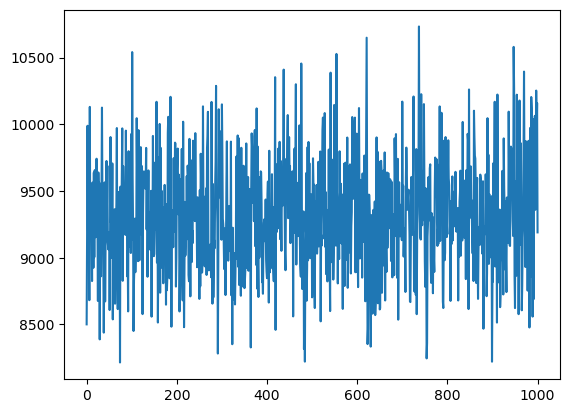

In [143]:
for i in range(num_simulations):
    balance = [8500]
    num_rolls = [0]
    #num_wins = 0
    while num_rolls[-1] < max_num_rolls:
        iter = roll_dice()
        costo_total = iter[0] + iter[1] + iter[2] 
        balance.append(costo_total)
        num_rolls.append(num_rolls[-1]+1)
plt.plot(num_rolls,balance)  
plt.show()    


In [148]:
# Estadísticas
media = np.mean(balance)
std = np.std(balance)


print(f"Media: ${media:.2f}")
print(f"Desviación estándar: ${std:.2f}")


Media: $9313.99
Desviación estándar: $420.22


## 4. Visualización

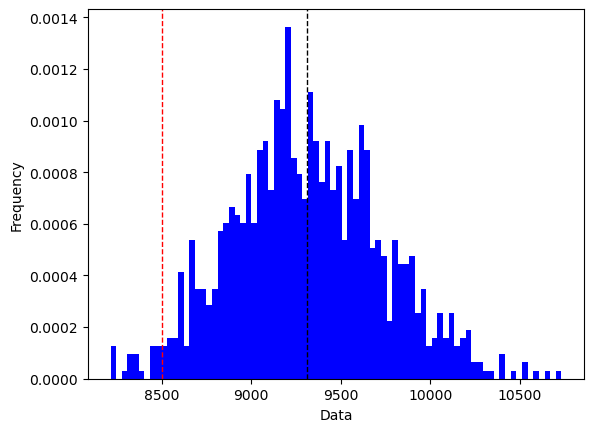

In [149]:
np.random.seed(42)
plt.hist(balance, density = True, bins = 80,color='blue') #density = False would make counts
plt.ylabel('Frequency') #Frequency
plt.xlabel('Data')
plt.axvline(np.mean(balance),color = 'k', linestyle='dashed',linewidth=1)
plt.axvline(costo_referencia,color = 'r', linestyle='dashed',linewidth=1)
plt.show()

In [137]:
print('Número de muestras: ', balance.__len__())
total_muestras = balance.__len__()

Número de muestras:  1001


In [138]:
costo_ok = [x for x in balance if x < costo_referencia]

In [139]:
num_costo_ok = costo_ok.__len__()
prob_costo_ref = num_costo_ok / total_muestras
print(f'La probabilidad que el costo sea menor al costo de referencia es: {prob_costo_ref*100:.2f}%')


La probabilidad que el costo sea menor al costo de referencia es: 2.00%


In [140]:
num_costo_ok

20

In [141]:
costo_ok[:5]

[8387.295375740108,
 8437.99595935687,
 8214.10972359821,
 8450.244734298492,
 8482.46618576274]

In [142]:
for i in range(0,100,5):
    print('Percentil ',i,'% = ',np.percentile(balance,i))

Percentil  0 % =  8214.10972359821
Percentil  5 % =  8654.852800090992
Percentil  10 % =  8784.322650871723
Percentil  15 % =  8883.443316335635
Percentil  20 % =  8959.952504705147
Percentil  25 % =  9031.319341840948
Percentil  30 % =  9086.051893058655
Percentil  35 % =  9146.674707601327
Percentil  40 % =  9191.191076730785
Percentil  45 % =  9233.228131756385
Percentil  50 % =  9292.370867203017
Percentil  55 % =  9348.73219275585
Percentil  60 % =  9403.868003394013
Percentil  65 % =  9460.398916000342
Percentil  70 % =  9539.776172374191
Percentil  75 % =  9602.957609427995
Percentil  80 % =  9654.404565344574
Percentil  85 % =  9745.299848137316
Percentil  90 % =  9872.245412704153
Percentil  95 % =  10046.013421179645


In [ ]:
def roll_dice():
    costo_estudios = np.random.normal(100,20)
    costo_diseño = np.random.triangular(100,150,200)
    costo_ingenieria = np.random.triangular(100,150,200)
    costo_implementacion = np.random.uniform(100,300)
    costo_pruebas = np.random.uniform(200,250)
    costo_aceptacion = np.random.triangular(100,150,300)

    return costo_estudios, costo_diseño, costo_ingenieria, costo_implementacion, costo_pruebas, costo_aceptacion

In [ ]:
a = roll_dice()
print(a[0],a[1],a[2],a[3],a[4],a[5])

109.93428306022466 163.39357582414019 155.2037102092727 131.2037280884873 207.79972601681013 124.10054193751657


In [ ]:
num_simulations = 1000
max_num_rolls = 1000

end_balance = []

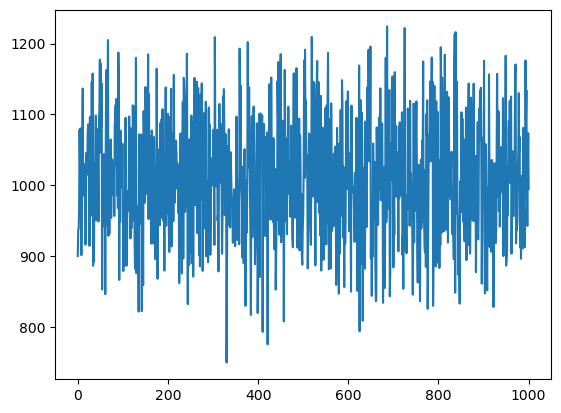

In [ ]:
for i in range(num_simulations):
    balance2 = [900]
    num_rolls = [0]
    num_wins = 0
    while num_rolls[-1] < max_num_rolls:
        iter = roll_dice()
        costo_total = iter[0] + iter[1] + iter[2] + iter[3] + iter[4] + iter[5]
        balance2.append(costo_total)
        num_rolls.append(num_rolls[-1]+1)
plt.plot(num_rolls,balance2)  
plt.show()    


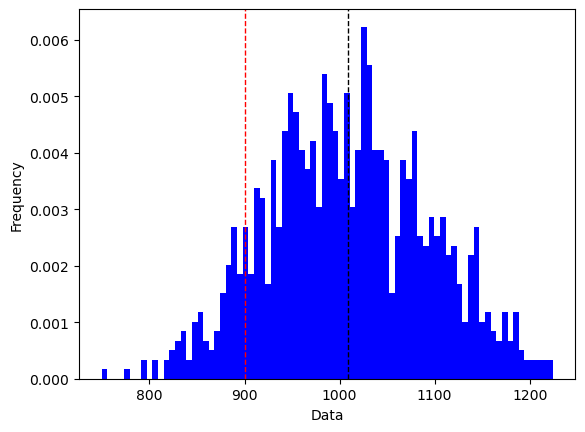

In [ ]:
np.random.seed(42)
plt.hist(balance2, density = True, bins = 80,color='blue') #density = False would make counts
plt.ylabel('Frequency') #Frequency
plt.xlabel('Data')
plt.axvline(np.mean(balance2),color = 'k', linestyle='dashed',linewidth=1)
plt.axvline(costo_referencia,color = 'r', linestyle='dashed',linewidth=1)
plt.show()

In [ ]:
print('Número de muestras: ', balance2.__len__())
total_muestras = balance2.__len__()
costo_ok = [x for x in balance2 if x < costo_referencia]
num_costo_ok = costo_ok.__len__()
prob_costo_ref= num_costo_ok/total_muestras
print(f'La probabilidad de que el costo sea menor al costo de referencia es: {prob_costo_ref*100:.2f}%')

Número de muestras:  1001
La probabilidad de que el costo sea menor al costo de referencia es: 9.99%


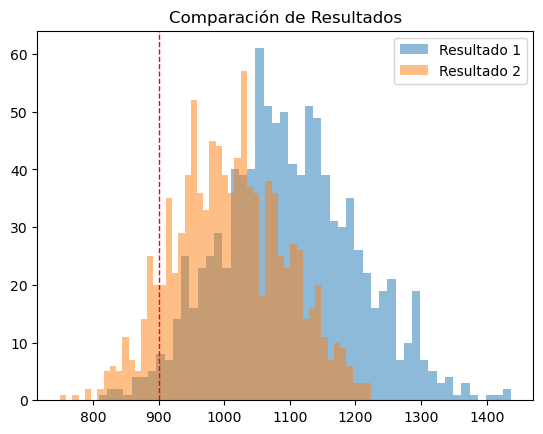

In [ ]:
import numpy as np
bins = np.linspace(0,2000,10)
plt.hist(balance, bins=50, alpha=0.5,label='Resultado 1')
plt.hist(balance2, bins=50, alpha=0.5,label='Resultado 2')
plt.legend(loc='upper right')
plt.title('Comparación de Resultados')
plt.axvline(costo_referencia, color ='r',linestyle='dashed',linewidth=1)
plt.show()

In [ ]:
for i in range(num_simulations):
    balance2 = [900]
    num_rolls = [0]
    num_wins = 0
    
    cestudios = []
    cdiseño = []
    cingenieria = []
    cimplementacion = []
    cpruebas = []
    caceptacion = []

    while num_rolls[-1] < 100:
        iter = roll_dice()
        costo_total = iter[0] + iter[1] + iter[2] + iter[3] + iter[4] + iter[5]

        cestudios.append(iter[0])
        cdiseño.append(iter[1])
        cingenieria.append(iter[2])
        cimplementacion.append(iter[3])
        cpruebas.append(iter[4])
        caceptacion.append(iter[5])

        balance2.append(costo_total)
        num_rolls.append(num_rolls[-1]+1)


In [ ]:
cestudios

[99.45921567716411,
 117.9205839557922,
 96.02017415495347,
 79.2996221708897,
 103.99905799287205,
 107.39015470562728,
 88.94015626679658,
 118.41068074612387,
 111.77241437726676,
 74.92467374262704,
 71.24715797860064,
 121.75156674662568,
 111.84358510811424,
 92.15017602988874,
 118.06593502987997,
 118.41945424260717,
 43.31506719403201,
 105.37086546008572,
 104.69540324725388,
 101.89635430191537,
 86.77494315662327,
 76.71903544474415,
 105.03330111048031,
 111.59500508603021,
 93.36512764171358,
 116.93561947803059,
 103.82347519111454,
 73.09389760961929,
 124.3470630780693,
 117.44753437887941,
 95.01813290917391,
 89.73799584031515,
 73.68767597644522,
 109.82122656111822,
 82.89404222629759,
 76.1469574244955,
 64.984270535055,
 85.33137777257606,
 108.8279458750952,
 65.83036068193584,
 89.48068354515233,
 122.5461371247578,
 71.24108723634602,
 90.48383566349781,
 108.26233895991892,
 105.9204203376356,
 120.2214854799787,
 85.51748251969887,
 107.56547882625202,
 77.0

In [ ]:
import pandas as pd
df1 = pd.DataFrame(cestudios, columns = ['Estudios'])
df2 = pd.DataFrame(cdiseño, columns = ['Diseño'])
df3 = pd.DataFrame(cingenieria, columns = ['Ing'])
df4 = pd.DataFrame(cimplementacion, columns = ['Implement'])
df5 = pd.DataFrame(cpruebas, columns = ['Pruebas'])
df6 = pd.DataFrame(caceptacion, columns = ['Acept'])

In [ ]:
df = df1
df['Diseño'] = df2
df['Ing'] = df3
df['Implement'] = df4
df['Pruebas'] = df5
df['Acept'] = df6

In [ ]:
df.sample(5)

,Estudios,Diseño,Ing,Implement,Pruebas,Acept
18,104.695403,129.420156,181.950307,237.534704,237.782657,174.344089
60,87.153439,116.258063,140.825324,193.148721,224.313964,151.709669
63,110.862232,108.511297,137.728738,278.573325,227.768198,192.978223
71,72.420643,141.104991,126.183407,278.863584,245.516722,240.034150
53,88.745671,138.923823,175.780613,101.203967,246.448857,126.010217


In [ ]:
df.corr()

,Estudios,Diseño,Ing,Implement,Pruebas,Acept
Estudios,1.000000,0.137341,-0.021022,0.061868,-0.110705,0.067536
Diseño,0.137341,1.000000,0.124196,0.122435,-0.161279,0.023481
Ing,-0.021022,0.124196,1.000000,-0.029573,0.240867,0.027126
Implement,0.061868,0.122435,-0.029573,1.000000,0.118689,0.112327
Pruebas,-0.110705,-0.161279,0.240867,0.118689,1.000000,0.076403
Acept,0.067536,0.023481,0.027126,0.112327,0.076403,1.000000


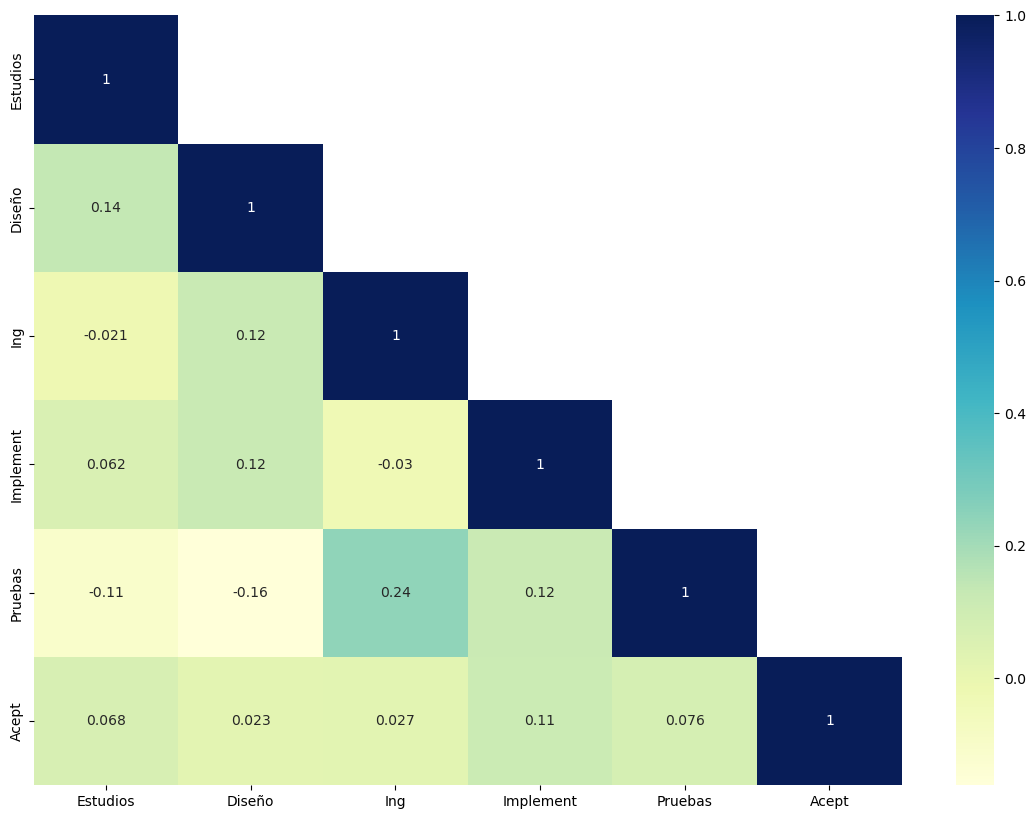

In [ ]:
import seaborn as sns
plt.figure(figsize=(14,10))
corr_df = corr = df.corr(method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap=sns.heatmap(df_lt,cmap='YlGnBu',annot=True)
plt.show()


In [ ]:
print(df.columns)
cols_num=['Estudios','Diseño','Ing','Implement','Pruebas','Acept']

Index(['Estudios', 'Diseño', 'Ing', 'Implement', 'Pruebas', 'Acept'], dtype='object')


/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_35091/4117366751.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column],ax=axes[i//3,i%3],kde=False)


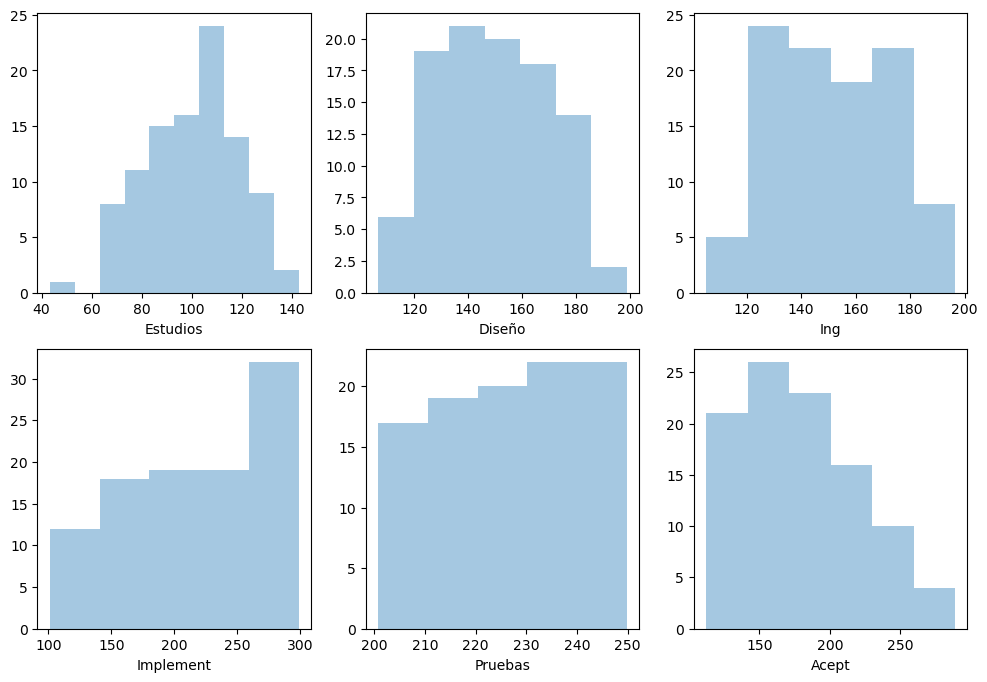

In [ ]:
fig, axes = plt.subplots(nrows=2,ncols = 3, figsize=(12,8))
for i, column in enumerate(cols_num):
    sns.distplot(df[column],ax=axes[i//3,i%3],kde=False)
plt.show()